# Illustration of simple stock rollover dynamics in light-duty vehicle sector to explore complementary vehicle electrification and vehicle miles travel (VMT) reduction.

In [1]:
# setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

First, we'll pick a time range. Let's create a year vector that ranges from 2010 to 2055.
(You'll see below why we need to start in the past.)

In [2]:
yyyy = np.arange(2010, 2056) # Remember that array indices run from 0 to n-1, where n is the range length.
# So this will stop in year 2055.

# List:
yyyy

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031,
       2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042,
       2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053,
       2054, 2055])

Text(0, 0.5, 'Calendar Year')

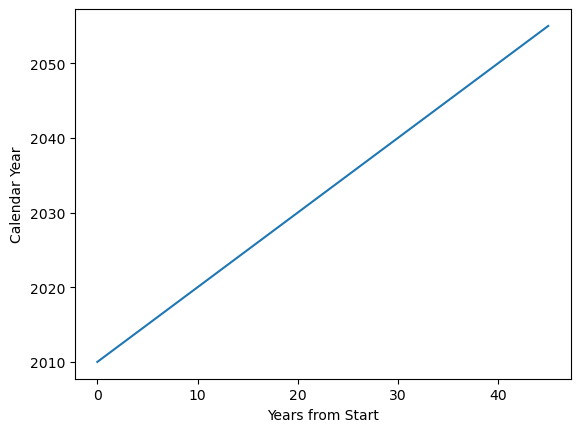

In [3]:
# Plot
plt.plot(yyyy)
plt.xlabel('Years from Start') # It inferred the x-axis
plt.ylabel('Calendar Year')

Let's keep it real simple and assume a constant vehicle fleet size for the US of 300 million vehicles.
You can get a more precise projection from [AEO Table 39](https://www.eia.gov/outlooks/aeo/data/browser/#/?id=49-AEO2026&cases=cb2026&sourcekey=0).

In [4]:
n_total_vehicles = 3e8 # i.e. 3 x 10^8 or 300 million

And still keeping it real simple, let's assume the simplest realistic survival profile for each vehicle.
Let's say each vehicle stays on the road (driving the same number of miles) for exactly 15 years and then is scrapped.
A more sophisticated survival profile would be a [Weibull Distribution](https://en.wikipedia.org/wiki/Weibull_distribution) with
a [shape parameter around 2](https://www.sciencedirect.com/science/article/pii/S2590198226002964) -- most vehicles last a few years
but then their likelihood of being retired starts to grow after a decade.

In [5]:
vehicle_life = 15 # yr

And we'll assume just two types of vehicles, gas\[oline\] and electric.

We need an initial condition. Let's seed our vehicle fleet in year 2010 with 300 million gasoline vehicles.
But first we'll need to create the container for our fleet projections.

In [6]:
# Create empty Dataframe with index of years and our vehicle stock columns.
fleet_projection = pd.DataFrame(index=yyyy, columns=['stock_gas', 'stock_EV'])
fleet_projection.head() # Show what the first 5 rows look like

,stock_gas,stock_EV
2010,NaN,NaN
2011,NaN,NaN
2012,NaN,NaN
2013,NaN,NaN
2014,NaN,NaN


We haven't filled in any data so it starts a NaN.
Now we seed the first year.

In [7]:
fleet_projection.loc[2010, 'stock_gas'] = n_total_vehicles
# .loc is the syntax for accessing a row. You can access a column with simple brackets but a complete .loc[rows, cols] is preferred when you are assigning values.
fleet_projection.loc[2010, 'stock_EV'] = 0
fleet_projection.head()

,stock_gas,stock_EV
2010,300000000.0,0
2011,NaN,NaN
2012,NaN,NaN
2013,NaN,NaN
2014,NaN,NaN


To advance from one year to the next, we'll need to track vehicle sales.
Since we're assuming a constant vehicle fleet and the simple survival profile, the total sales
each year will be exactly 1/15 times the fleet size.

In [8]:
n_total_sales = n_total_vehicles / 15 # vehicles per yr
print(np.format_float_scientific(n_total_sales)) # to avoid having to count zeros

2.e+07


That's 20M vehicles per year.

In [9]:
fleet_projection['sales_gas'] = np.nan
fleet_projection['sales_EV'] = np.nan
fleet_projection.loc[2010, 'sales_gas'] = n_total_sales
fleet_projection.loc[2010, 'sales_EV'] = 0
fleet_projection.head()

,stock_gas,stock_EV,sales_gas,sales_EV
2010,300000000.0,0,20000000.0,0.0
2011,NaN,NaN,NaN,NaN
2012,NaN,NaN,NaN,NaN
2013,NaN,NaN,NaN,NaN
2014,NaN,NaN,NaN,NaN


Now the key step is to advance the stocks from year to year. To do that, we'll retire all the vehicles
that were sold 15 years ago and then add the previous year's sales.
To make this easy, we'll assume zero EVs sold for the first 15 years.

In [10]:
fleet_projection.loc[yyyy[:15], ['stock_gas', 'stock_EV', 'sales_gas', 'sales_EV']] = [n_total_vehicles, 0, n_total_sales, 0]
# This is a complicated expression to illustrate more sophisticated pandas syntax.
# We are assigning the identical rows in bulk in 1 line. We could have just written four separate lines like we did above for the first row,
# one for each column.
# In general the syntax is 
# x.loc[row_range, column_range] = vals

fleet_projection.head(15) # Show the first 15 rows

,stock_gas,stock_EV,sales_gas,sales_EV
2010,300000000.0,0,20000000.0,0.0
2011,300000000.0,0,20000000.0,0.0
2012,300000000.0,0,20000000.0,0.0
2013,300000000.0,0,20000000.0,0.0
2014,300000000.0,0,20000000.0,0.0
2015,300000000.0,0,20000000.0,0.0
2016,300000000.0,0,20000000.0,0.0
2017,300000000.0,0,20000000.0,0.0
2018,300000000.0,0,20000000.0,0.0
2019,300000000.0,0,20000000.0,0.0


OK now beginning in year 2025, we're going to set the stock based on the sales from the previous year,
subtracting the vehicles sold 15 yr ago.
We could make this more elegant and efficient using a function and operating on the entire dataframe at once,
but we'll demonstrate using a simple for loop.

But first let's just do year 2025.

In [11]:
fleet_projection.loc[2025, 'stock_gas'] = fleet_projection.loc[2024, 'stock_gas'] # Starting point
- fleet_projection.loc[2025 - vehicle_life, 'sales_gas'] # Retirement
+ fleet_projection.loc[2024, 'sales_gas'] # Last year's sales
# You'll notice we're basically just subbing in old sales for new sales.

# Do the same for electric
fleet_projection.loc[2025, 'stock_EV'] = fleet_projection.loc[2024, 'stock_EV'] # Starting point
- fleet_projection.loc[2025 - vehicle_life, 'sales_EV'] # Retirement
+ fleet_projection.loc[2024, 'sales_EV'] # Last year's sales

fleet_projection.loc[2025]

stock_gas    300000000.0
stock_EV               0
sales_gas            NaN
sales_EV             NaN
Name: 2025, dtype: object

Now we need to assume a sales trajectory for our projection. This is the first SCENARIO assumption we're making,
as opposed to defining a simple Baseline model from first principles.

This is typically modeled using an "S-curve".
To simplify, we'll use a piecewise linear, increasing 1M/yr each yr from 2025 to 2030, then 2M/yr for the next 5 yr,
and then 1M/yr to 2040.

Let's define a dimensionless sales_share_EV variable to make this easier.

<Axes: >

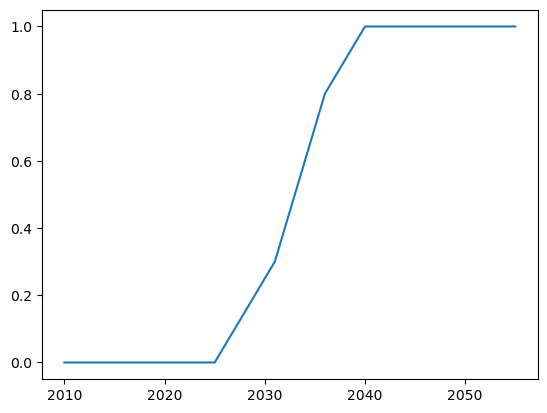

In [31]:
sales_share_EV = pd.Series(index=yyyy)
sales_share_EV.loc[:2025] = 0
sales_share_EV.loc[2026:2030] = np.arange(0.05, 0.3, 0.05) # You can use arange for floats. The syntax is (start, stop [+ 1 step], step).
sales_share_EV.loc[2031:2035] = np.arange(0.3, 0.8, 0.1)
sales_share_EV.loc[2036:2040] = np.arange(0.8, 1.05, 0.05)
sales_share_EV.loc[2041:2055] = 1
sales_share_EV.plot()